In [1]:
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
import muspan as ms



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sarapatti/miniforge3/envs/muspan/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 739, in

In [2]:
# Base project path
base_path = Path(
    "/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/"
)

# Input

# Output directories
outpath = base_path / "output" / "muspan" / "nb_clustering"
data_dir = outpath / "data"
plots_dir = outpath / "plots"

# Create directories
for path in [outpath]:
    path.mkdir(parents=True, exist_ok=True)


In [3]:
domain = ms.io.load_domain("/Volumes/phenotypingsputumasthmaticsaurorawellcomea1/live/Sara_Patti/009_ST_Xenium/output/muspan/domains/IPF_RBH_16_muspan_domain.muspan")

MuSpAn domain loaded successfully. Domain summary:
Domain name: IPF_RBH_16
Number of objects: 183019
Collections: ['Cell boundaries', 'Nucleus boundaries', 'Transcripts', 'Cell centroids']
Labels: ['Cell ID', 'Transcript Counts', 'Cell Area', 'Nucleus Area', 'Transcript ID', 'Cell Type'] 
Networks: ['Delaunay CC', 'Delaunay CC filtered', 'Proximity_30um'] 
Distance matrices: []


In [56]:
khop=5

In [57]:
# Perform neighbourhood clustering on the dataset using KNN and minibatchkmeans
neighbourhood_enrichment_matrix, consistent_global_labels, unique_cluster_labels = ms.networks.cluster_neighbourhoods(
    domain,  # The domain dataset
    label_name='Cell Type',  # The label to use for clustering
    network_kwargs=dict(network_type='Delaunay', max_edge_distance=30, min_edge_distance=0),  # The network parameters
    k_hops=khop,  # The number of hops to consider for the neighbourhood
    neighbourhood_label_name='Neighbourhood ID',  # Name for the neighbourhood label
    cluster_method='minibatchkmeans',  # Clustering method
    cluster_parameters={'n_clusters': 8,'random_state':0},  # Parameters for the clustering method
    neighbourhood_enrichment_as='log-fold' # Neighbourhood enrichment as log-fold
)


In [58]:
# Create a DataFrame from the neighbourhood enrichment matrix
df_ME_id = pd.DataFrame(data=neighbourhood_enrichment_matrix, index=unique_cluster_labels, columns=consistent_global_labels)
df_ME_id.index.name = 'Neighbourhood ID'
df_ME_id.columns.name = 'Cell Type ID'

# Filter out sentinel values before computing range
finite_vals = df_ME_id.values[np.isfinite(df_ME_id.values) & (np.abs(df_ME_id.values) < 1e300)]
vmin = np.floor(finite_vals.min())
vmax = np.ceil(finite_vals.max())

df_plot = df_ME_id.clip(lower=vmin, upper=vmax)

plot_vimin = -5
plot_vimax = 5

Text(0.5, 1.04, 'Neighbourhood Enrichment Clusteringclusters)')

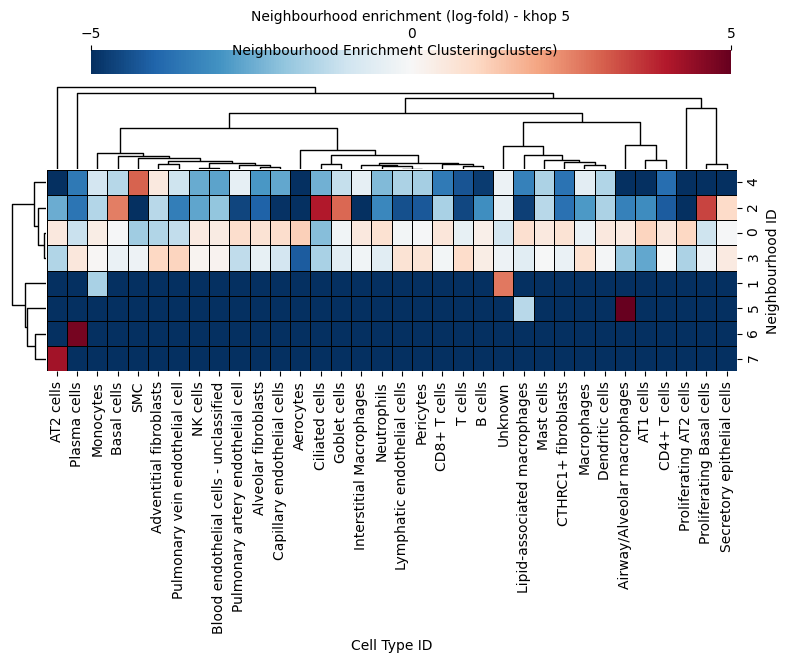

In [ ]:
# Visualize the neighbourhood enrichment matrix using a clustermap
sns.clustermap(
    df_plot,
    xticklabels=consistent_global_labels,
    yticklabels=unique_cluster_labels,
    figsize=(8, 6),
    cmap='RdBu_r',
    dendrogram_ratio=(.05, .3),
    col_cluster=True,
    row_cluster=True,
    square=True,
    linewidths=0.5,
    linecolor='black',
    vmin=plot_vimin,
    vmax=plot_vimax,
    cbar_kws=dict(use_gridspec=False, location="top", 
    label=f'Neighbourhood enrichment (log-fold)', ticks=[plot_vimin, 0, plot_vimax]),
    cbar_pos=(0.12, 0.99, 0.8, 0.04),
    tree_kws={'linewidths': 1, 'color': 'black'}
)

plt.suptitle("Neighbourhood Enrichment Clusteringclusters)", fontsize=10, y=1.04)

(<Figure size 1000x800 with 2 Axes>, <Axes: >)

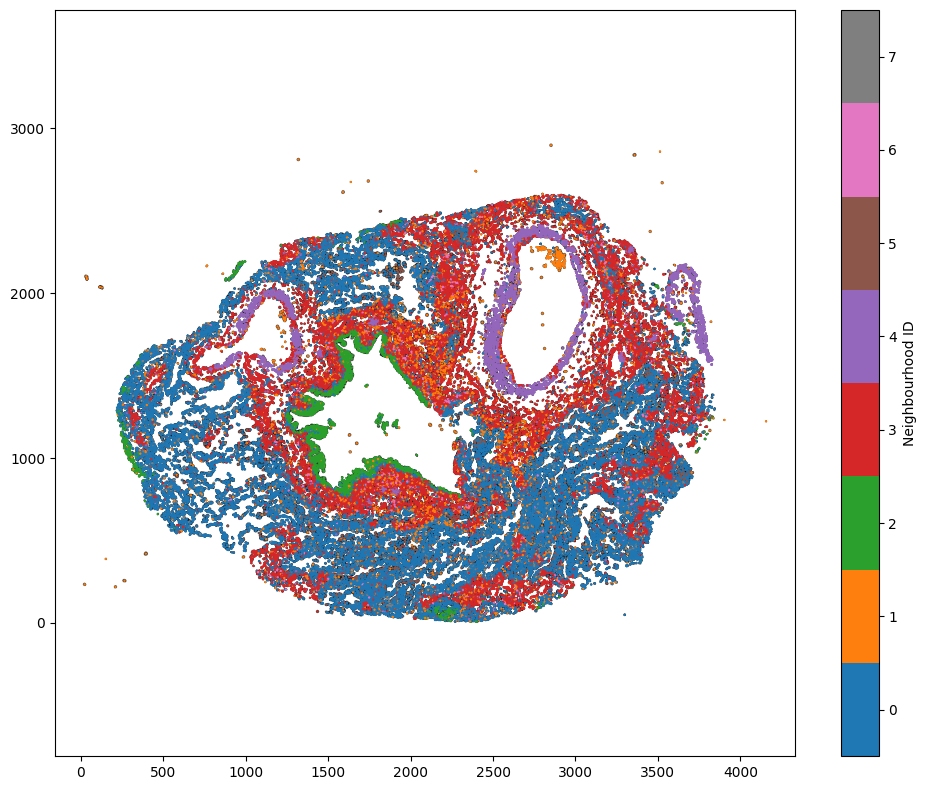

In [60]:
ms.visualise.visualise(domain, color_by='Neighbourhood ID', marker_size=0.5)

AttributeError: 'numpy.ndarray' object has no attribute 'to_list'